# Practice quiz: Tree ensembles

---

## Question 1: Tree Ensemble (Random Forest)

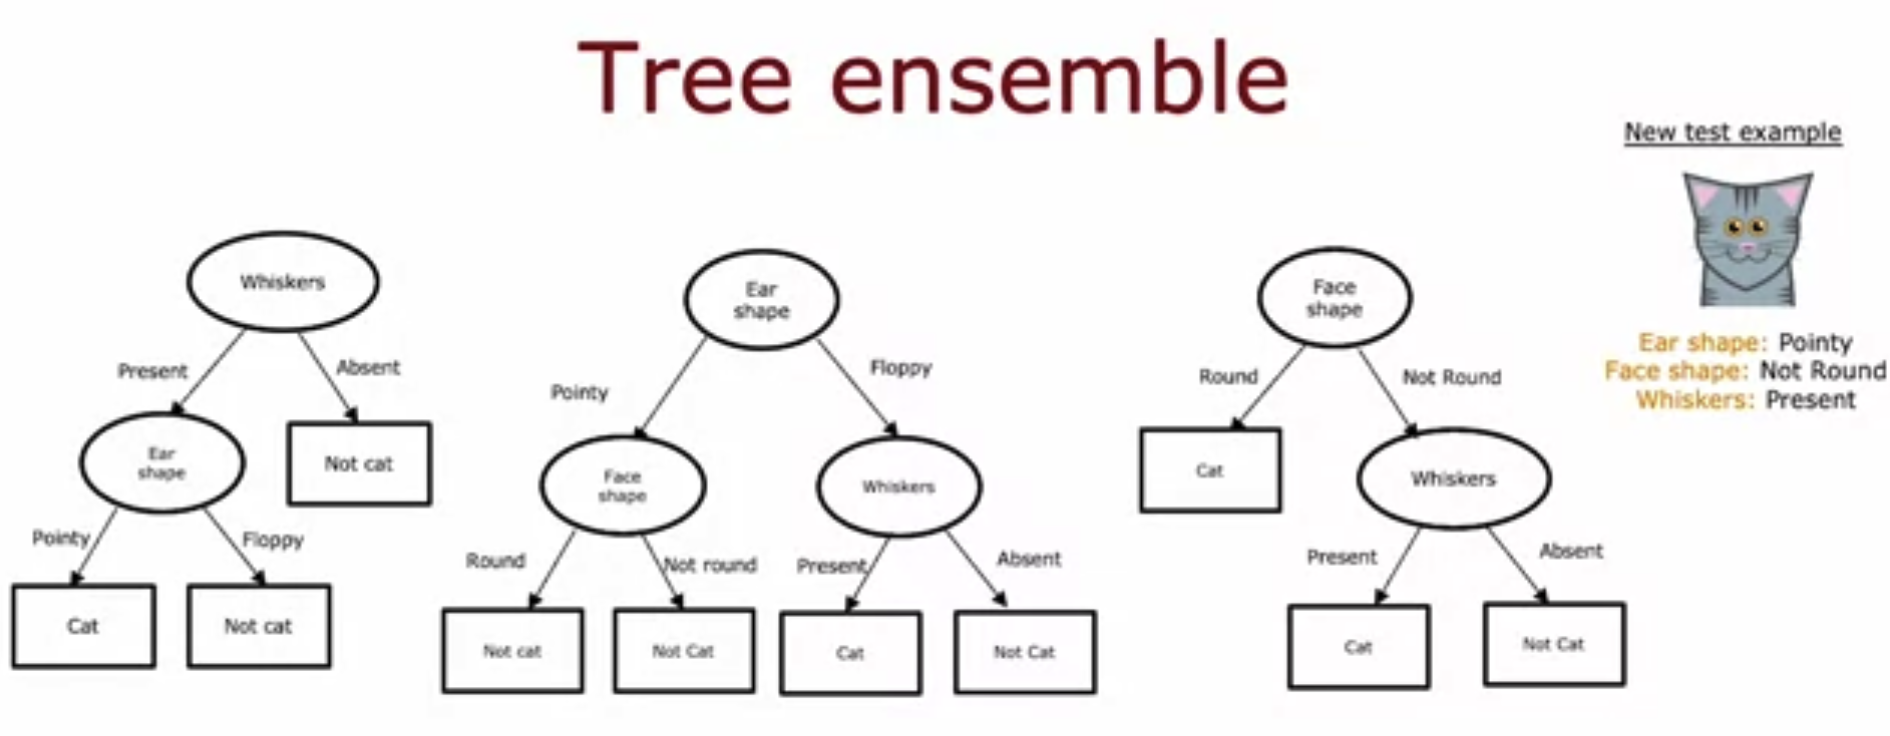

**Question:**
For the random forest, how do you build each individual tree so that they are not all identical to each other?

**Options:**
- Sample the training data with replacement and select a random subset of features to build each tree
- Sample the training data without replacement
- Train the algorithm multiple times on the same training set. This will naturally result in different trees.
- If you are training B trees, train each one on 1/B of the training set, so each tree is trained on a distinct set of examples.

### Correct Answer
**Option 1:** Sample the training data with replacement and select a random subset of features to build each tree

### Explanation
**Random Forests** rely on a technique called **Bagging (Bootstrap Aggregating)** to create diversity among the trees. If every tree were identical, the ensemble would be no better than a single tree. To prevent this, randomness is introduced in two ways:

1.  **Data Randomness (Bootstrap):** Each tree is trained on a random subset of the training data, sampled **with replacement**. This means some examples might appear multiple times in a tree's dataset, while others might not appear at all.
2.  **Feature Randomness:** When deciding where to split a node, the algorithm does not consider *all* available features. Instead, it randomly selects a **subset of features** to evaluate. This forces the trees to look at different patterns in the data.

**Why the other options are incorrect:**
-   **Option 2:** Sampling *without* replacement is standard cross-validation or simple splitting. While it creates different datasets, the standard Random Forest algorithm specifically uses *bootstrap* sampling (with replacement) to ensure each tree sees a dataset of the same size as the original, but with different composition.
-   **Option 3:** Decision Tree algorithms (like CART) are **deterministic**. If you feed the exact same data into the algorithm twice, it will produce the exact same tree. It will not "naturally" result in different trees without introduced randomness.
-   **Option 4:** Partitioning the data (giving each tree 1/B of the data) is inefficient. It means each tree sees much less data than the full dataset. Bootstrap sampling allows each tree to see $N$ examples (where $N$ is the dataset size), maximizing the information each tree can learn while still maintaining diversity.

**Real-World Example:**
Imagine a committee of doctors diagnosing a patient.
-   **Without Randomness:** Every doctor reads the exact same chart and looks at the exact same symptoms in the exact same order. They will all come to the exact same conclusion. If they are all wrong, the committee is wrong.
-   **With Randomness (Random Forest):** Each doctor gets a slightly different version of the patient's history (Data Sampling) and is asked to focus on different symptoms first (Feature Sampling). One looks closely at heart rate, another at temperature. They vote on the diagnosis. This diversity makes the group's final decision more robust.

---



## Question 2: Decision Tree vs. Neural Network

**Question:**
You are choosing between a decision tree and a neural network for a classification task where the input $x$ is a 100x100 resolution image. Which would you choose?

**Options:**
- A neural network, because the input is unstructured data and neural networks typically work better with unstructured data.
- A decision tree, because the input is unstructured and decision trees typically work better with unstructured data.
- A neural network, because the input is structured data and neural networks typically work better with structured data.
- A decision tree, because the input is structured data and decision trees typically work better with structured data.

### Correct Answer
**Option 1:** A neural network, because the input is unstructured data and neural networks typically work better with unstructured data.

### Explanation
In Machine Learning, data is often categorized into two types:
1.  **Structured Data:** Data that fits neatly into rows and columns (like an Excel spreadsheet). Examples: Housing prices, customer age, salary. **Decision Trees** and Gradient Boosting (like XGBoost) often excel here.
2.  **Unstructured Data:** Data that does not have a pre-defined model or organization. Examples: **Images**, Audio, Text.

**Images** (like a 100x100 pixel grid) are classic **unstructured data**.
-   **Neural Networks (specifically Convolutional Neural Networks or CNNs)** are designed to handle this. They can learn spatial hierarchies (e.g., pixels form edges, edges form shapes, shapes form objects).
-   **Decision Trees** struggle with raw image data because a 100x100 image has 10,000 input features (pixels). Finding the best split among 10,000 features is computationally heavy, and trees do not naturally understand that pixel (1,1) is related to pixel (1,2).

**Why the other options are incorrect:**
-   **Option 2 & 4:** These suggest using a Decision Tree for images. While possible with heavy feature engineering, standard decision trees are generally poor performers on raw pixel data compared to neural networks.
-   **Option 3:** This incorrectly classifies images as "structured data." While pixels are arranged in a grid, the *semantic meaning* is not structured like a database table.

**Real-World Example:**
-   **Structured Data Task:** Predicting if a loan applicant will default. You have clear columns: `Income`, `Credit Score`, `Debt`. A Decision Tree is great here ("If Income < 30k AND Credit Score < 600, then Reject").
-   **Unstructured Data Task:** Identifying if a photo contains a cat. You have a grid of colored dots. A Neural Network is needed to recognize that a specific arrangement of brown and white dots forms "ears" and "whiskers."

---

## Question 3: Sampling with Replacement

**Question:**
What does sampling with replacement refer to?

**Options:**
- Drawing a sequence of examples where, when picking the next example, first replacing all previously drawn examples into the set we are picking from.
- Drawing a sequence of examples where, when picking the next example, first remove all previously drawn examples from the set we are picking from.
- It refers to a process of making an identical copy of the training set.
- It refers to using a new sample of data that we use to permanently overwrite (that is, to replace) the original data.

### Correct Answer
**Option 1:** Drawing a sequence of examples where, when picking the next example, first replacing all previously drawn examples into the set we are picking from.

### Explanation
**Sampling with Replacement** (often called **Bootstrap Sampling**) is a statistical method used to create diverse datasets from a single original dataset.

Imagine a bag containing 10 marbles numbered 1 to 10.
1.  You reach in and pick Marble #3.
2.  You record the number "3".
3.  **Crucial Step:** You put Marble #3 **back** into the bag.
4.  You reach in again. Marble #3 could be picked again!

This ensures that every draw is independent and the probability of picking any specific item remains constant ($1/10$) for every draw. In Random Forests, this allows a single training example to appear multiple times in the training set for a specific tree.

**Why the other options are incorrect:**
-   **Option 2:** This describes sampling **without** replacement. Once you pick a marble, you keep it out. This reduces the pool size for the next draw.
-   **Option 3:** Making an identical copy is just duplication (`dataset_copy = dataset.copy()`). It does not involve random selection or the possibility of duplicates/omissions inherent in sampling.
-   **Option 4:** This interprets "replace" in the computer science sense of "overwriting a file." In statistics, "replacement" refers to returning the item to the sampling pool.

**Real-World Example:**
Think of a raffle drum.
-   **With Replacement:** You pull a ticket, check the number, and drop it back in. Someone else could pull the exact same ticket number immediately after you.
-   **Without Replacement:** You pull a ticket and keep it. That ticket number is now gone from the drum and cannot be won again.

---

## Summary Table

| Concept | Key Takeaway | Real-World Analogy |
| :--- | :--- | :--- |
| **Random Forest** | Uses **Bagging** (data sampling with replacement) + **Feature Subsampling** to create diverse trees. | A committee of experts where each expert studies a slightly different case file and focuses on different clues. |
| **NN vs. Tree** | **Neural Networks** for Unstructured Data (Images, Audio). **Trees** for Structured Data (Tables). | NNs are like artists recognizing shapes in a painting. Trees are like accountants analyzing rows in a spreadsheet. |
| **Sampling w/ Replacement** | Items are returned to the pool after selection, allowing duplicates in the sample. | Drawing a name from a hat, reading it, and putting it back before drawing again. |